# 1: Business Understanding

## Business Questions
This project aims to analyze hospital patient satisfaction and answer the following key business questions:

1- What is the distribution of patient satisfaction across healthcare facilities?

2- Does the number of completed surveys influence satisfaction scores?

3- How does the survey response rate impact patient satisfaction?

4- Which hospital characteristics are most strongly associated with satisfaction levels?

## Import Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

 # 2: Data Understanding

## Dataset Description
The dataset contains hospital-level survey data (HCAHPS), including:
- Patient satisfaction measures
- Survey response statistics
- Hospital identifiers

Each hospital appears multiple times (long format), requiring transformation.

In [7]:

# Load raw dataset
df = pd.read_csv("HCAHPS-Hospital.csv", low_memory=False)

# Basic info
df.shape
df.columns
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325856 entries, 0 to 325855
Data columns (total 22 columns):
 #   Column                                 Non-Null Count   Dtype 
---  ------                                 --------------   ----- 
 0   Facility ID                            325856 non-null  object
 1   Facility Name                          325856 non-null  object
 2   Address                                325856 non-null  object
 3   City/Town                              325856 non-null  object
 4   State                                  325856 non-null  object
 5   ZIP Code                               325856 non-null  int64 
 6   County/Parish                          325856 non-null  object
 7   Telephone Number                       325856 non-null  object
 8   HCAHPS Measure ID                      325856 non-null  object
 9   HCAHPS Question                        325856 non-null  object
 10  HCAHPS Answer Description              325856 non-null  object
 11  

,ZIP Code
count,325856.000000
mean,54206.306553
std,26930.786614
min,603.000000
25%,33047.500000
50%,55779.500000
75%,76208.000000
max,99929.000000


In [8]:
df.dtypes

Facility ID                              object
Facility Name                            object
Address                                  object
City/Town                                object
State                                    object
ZIP Code                                  int64
County/Parish                            object
Telephone Number                         object
HCAHPS Measure ID                        object
HCAHPS Question                          object
HCAHPS Answer Description                object
Patient Survey Star Rating               object
Patient Survey Star Rating Footnote      object
HCAHPS Answer Percent                    object
HCAHPS Answer Percent Footnote           object
HCAHPS Linear Mean Value                 object
Number of Completed Surveys              object
Number of Completed Surveys Footnote     object
Survey Response Rate Percent             object
Survey Response Rate Percent Footnote    object
Start Date                              

The dataset contains a mix of categorical (object) and numerical variables.

Most columns are stored as object type, including text-based information such as hospital details (e.g., Facility Name, City, State) and survey responses (e.g., HCAHPS Question, Answer Description).
Some columns that should be numeric (e.g., HCAHPS Answer Percent, Number of Completed Surveys, Survey Response Rate Percent) are also stored as objects, indicating they require data cleaning and conversion before analysis.
Only a few columns, such as ZIP Code, are already in numeric format (int64).

In [9]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

Patient Survey Star Rating Footnote      95.536679
HCAHPS Answer Percent Footnote           73.252295
Survey Response Rate Percent Footnote    64.336394
Number of Completed Surveys Footnote     64.336394
Facility ID                               0.000000
Facility Name                             0.000000
ZIP Code                                  0.000000
State                                     0.000000
City/Town                                 0.000000
Address                                   0.000000
HCAHPS Question                           0.000000
County/Parish                             0.000000
HCAHPS Measure ID                         0.000000
Telephone Number                          0.000000
HCAHPS Answer Percent                     0.000000
Patient Survey Star Rating                0.000000
HCAHPS Answer Description                 0.000000
HCAHPS Linear Mean Value                  0.000000
Number of Completed Surveys               0.000000
Survey Response Rate Percent   

Most columns in the dataset have no missing values, indicating strong data completeness for the main variables.
However, several footnote columns contain a high percentage of missing values (64%–95%). These columns provide supplementary information and are not essential for the analysis.
Therefore, they can be safely dropped without affecting the quality or reliability of the results.

## Data Preparation
The dataset is cleaned and transformed into a usable format for analysis.


In [3]:
def prepare_hcahps_data(file_path):
    """
    Load and prepare the HCAHPS hospital dataset for analysis.

    This function:
    - Selects relevant columns
    - Converts columns to numeric format
    - Removes missing values
    - Transforms data from long format to wide format (pivot)
    - Aggregates survey-related features
    - Merges datasets into a final cleaned dataset

    Args:
        file_path (str): Path to the CSV dataset file

    Returns:
        pandas.DataFrame: Cleaned dataset ready for analysis and modeling
    """

    # Load dataset
    df = pd.read_csv(file_path, low_memory=False)

    # Select relevant columns
    df = df[
        [
            'Facility ID',
            'HCAHPS Measure ID',
            'HCAHPS Answer Percent',
            'Number of Completed Surveys',
            'Survey Response Rate Percent'
        ]
    ]

    # Convert numeric columns
    df['HCAHPS Answer Percent'] = pd.to_numeric(
        df['HCAHPS Answer Percent'], errors='coerce'
    )
    df['Number of Completed Surveys'] = pd.to_numeric(
        df['Number of Completed Surveys'], errors='coerce'
    )
    df['Survey Response Rate Percent'] = pd.to_numeric(
        df['Survey Response Rate Percent'], errors='coerce'
    )

    # Drop missing values
    df = df.dropna()

    # Pivot (transform long → wide)
    df_pivot = df.pivot_table(
        index='Facility ID',
        columns='HCAHPS Measure ID',
        values='HCAHPS Answer Percent',
        aggfunc='mean'
    )

    # Reset index
    df_pivot = df_pivot.reset_index()

    # Add survey-related features
    survey_df = df.groupby('Facility ID')[[
        'Number of Completed Surveys',
        'Survey Response Rate Percent'
    ]].mean().reset_index()

    # Merge datasets
    final_df = pd.merge(df_pivot, survey_df, on='Facility ID')

    # Drop rows with missing values after pivot
    final_df = final_df.dropna()

    return final_df


In [3]:
# Run function
df_model = prepare_hcahps_data("HCAHPS-Hospital.csv")

In [4]:
df_model.head()

,Facility ID,H_CLEAN_HSP_A_P,H_CLEAN_HSP_SN_P,H_CLEAN_HSP_U_P,H_COMP_1_A_P,H_COMP_1_SN_P,H_COMP_1_U_P,H_COMP_2_A_P,H_COMP_2_SN_P,H_COMP_2_U_P,...,H_RECMND_DN,H_RECMND_DY,H_RECMND_PY,H_SIDE_EFFECTS_A_P,H_SIDE_EFFECTS_SN_P,H_SIDE_EFFECTS_U_P,H_SYMPTOMS_N_P,H_SYMPTOMS_Y_P,Number of Completed Surveys,Survey Response Rate Percent
0,010001,71.0,11.0,18.0,76.0,6.0,18.0,80.0,4.0,16.0,...,3.0,77.0,20.0,45.0,28.0,27.0,10.0,90.0,952.0,17.0
1,010005,66.0,13.0,21.0,77.0,6.0,17.0,82.0,4.0,14.0,...,8.0,63.0,29.0,40.0,38.0,22.0,12.0,88.0,705.0,17.0
2,010006,63.0,16.0,21.0,75.0,6.0,19.0,73.0,9.0,18.0,...,11.0,56.0,33.0,40.0,40.0,20.0,14.0,86.0,1814.0,18.0
3,010007,59.0,15.0,26.0,79.0,5.0,16.0,86.0,3.0,11.0,...,7.0,68.0,25.0,47.0,32.0,21.0,7.0,93.0,97.0,17.0
4,010011,63.0,14.0,23.0,78.0,6.0,16.0,79.0,6.0,15.0,...,8.0,69.0,23.0,43.0,36.0,21.0,15.0,85.0,887.0,21.0


# 3: Exploratory Data Analysis (EDA)

### 1. Distribution of Patient Satisfaction

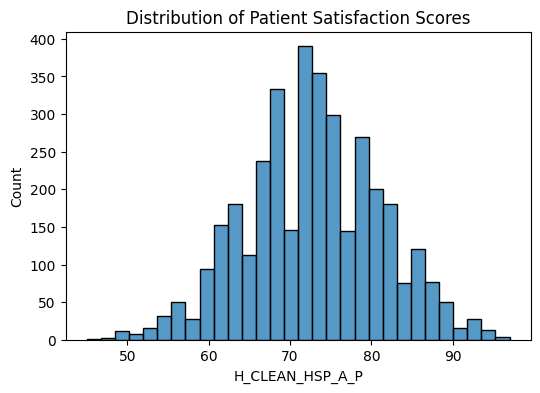

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df_model.iloc[:, 1], bins=30)
plt.title("Distribution of Patient Satisfaction Scores")
plt.show()

#### Interpretation:
The distribution of patient satisfaction scores is approximately normal, with most hospitals scoring between 65 and 85. The concentration around 70–75 suggests that the majority of hospitals provide moderate to high levels of patient satisfaction, while very few hospitals perform extremely poorly or exceptionally well.

###  2. Surveys vs Satisfaction

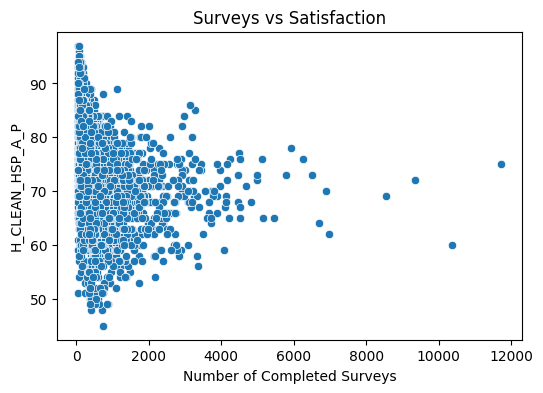

In [6]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Number of Completed Surveys',
    y=df_model.iloc[:, 1],
    data=df_model
)
plt.title("Surveys vs Satisfaction")
plt.show()

#### Interpretation:
The relationship between the number of completed surveys and satisfaction scores appears weak. Hospitals with fewer surveys show a wide variation in satisfaction, while those with more surveys exhibit more stable scores. This suggests that higher survey volumes may improve the reliability of satisfaction measurements, but do not strongly influence satisfaction itself.

### 3. Response Rate vs Satisfication

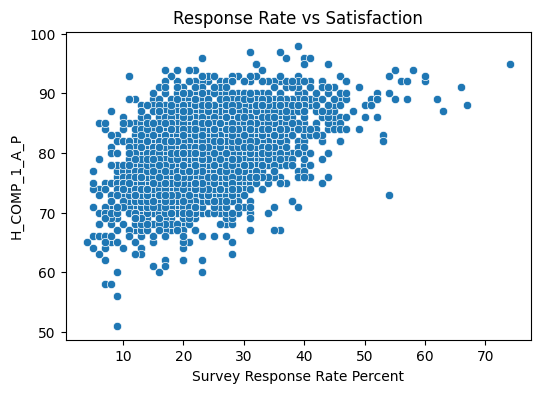

In [7]:

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Survey Response Rate Percent',
    y='H_COMP_1_A_P',
    data=df_model
)
plt.title("Response Rate vs Satisfaction")
plt.show()


#### Interpretation:
There is a clear positive relationship between survey response rate and patient satisfaction. Hospitals with higher response rates tend to achieve higher satisfaction scores, suggesting that greater patient engagement is associated with better perceived care quality.

### 4. Top Features Influencing Satisfaction

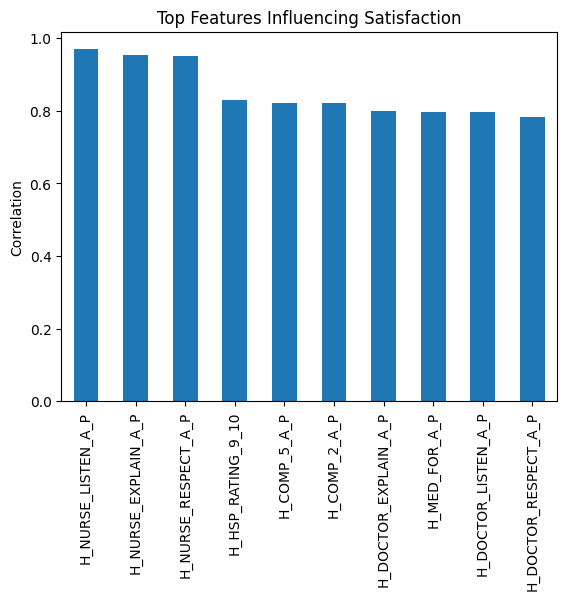

In [8]:
numeric_df = df_model.select_dtypes(include=[np.number])

target = 'H_COMP_1_A_P'

corr_with_target = numeric_df.corr()[target].sort_values(ascending=False)

# Remove target itself
corr_with_target = corr_with_target.drop(target)

# Plot
corr_with_target.head(10).plot(kind='bar')
plt.title("Top Features Influencing Satisfaction")
plt.ylabel("Correlation")
plt.show()

#### Interpretation:
The strongest predictors of patient satisfaction are related to nurse communication, including listening carefully, explaining clearly, and treating patients with respect. These factors show very high correlations (above 0.9), indicating that interpersonal care quality plays a critical role in shaping patient experiences.

Additionally, overall hospital ratings and doctor communication measures also show strong positive relationships with satisfaction, suggesting that high-performing hospitals tend to provide consistently positive experiences across multiple aspects of care

#  4: Data Modeling (Linear Regression)

In [9]:
target_column = df_model.columns[1]  # first measure column

## Feature Selection

In [10]:
df_clean = df_model.drop(columns=['Facility ID'])
df_clean = df_clean.select_dtypes(include=['float64', 'int64']).dropna()

X = df_clean[[
    'Number of Completed Surveys',
    'Survey Response Rate Percent',
    'H_HSP_RATING_0_6',
    'H_HSP_RATING_7_8',
    'H_HSP_RATING_9_10'
]]

y = df_clean['H_COMP_1_A_P']



##  Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##  Train Model

In [12]:
model = LinearRegression() 

In [13]:
# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


# 5: Model Evaluation

In [14]:
# Performance Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", round(mse, 2))
print("R²:", round(r2, 2))

MSE: 7.88
R²: 0.74


The model achieved an R² score of 0.74, meaning it explains 74% of the variation in patient satisfaction scores. This indicates a strong predictive performance. The Mean Squared Error (7.88) shows that prediction errors are relatively small, suggesting that the model provides reasonably accurate estimates

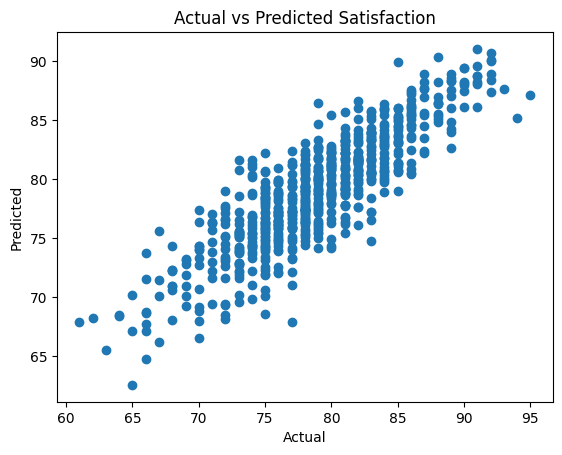

In [15]:
# Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Satisfaction")
plt.show()

This predicted score represents expected patient satisfaction for a hospital with average characteristics. It suggests that survey responses and hospital ratings have measurable predictive power.

In [16]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(importance.sort_values(by='Coefficient', ascending=False))

                        Feature  Coefficient
4             H_HSP_RATING_9_10     0.346714
1  Survey Response Rate Percent     0.048818
3              H_HSP_RATING_7_8     0.020077
0   Number of Completed Surveys    -0.000880
2              H_HSP_RATING_0_6    -0.366791


#  6: Prediction Example

In [18]:
# Create sample hospital data (example values)
new_data = pd.DataFrame([X.mean()])

prediction = model.predict(new_data)

print("Predicted Satisfaction Score:", prediction[0])

Predicted Satisfaction Score: 79.32596436758662
